#### (1) 데이터 불러오기 및 확인하기

데이터 정보 확인

In [33]:
# 필요 라이브러리 불러오기
import numpy as np
import pandas as pd

# 데이터 로드 
df = pd.read_csv('../datasets/CVD_cleaned.csv')

# 데이터 정보 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   General_Health                308854 non-null  str    
 1   Checkup                       308854 non-null  str    
 2   Exercise                      308854 non-null  str    
 3   Heart_Disease                 308854 non-null  str    
 4   Skin_Cancer                   308854 non-null  str    
 5   Other_Cancer                  308854 non-null  str    
 6   Depression                    308854 non-null  str    
 7   Diabetes                      308854 non-null  str    
 8   Arthritis                     308854 non-null  str    
 9   Sex                           308854 non-null  str    
 10  Age_Category                  308854 non-null  str    
 11  Height_(cm)                   308854 non-null  float64
 12  Weight_(kg)                   308854 non-null  float64


데이터 프레임 확인

In [ ]:
# 데이터 프레임 상위 5개의 행 확인
df['Heart_Disease'].head()

0     No
1    Yes
2     No
3    Yes
4     No
Name: Heart_Disease, dtype: str

#### (2) 데이터 전처리하기

원핫 인코딩 진행

In [36]:
# 대상 컬럼 리스트 
one_hot_columns = [ 
    'General_Health', 'Checkup', 'Diabetes', 'Exercise', 
    'Skin_Cancer', 'Other_Cancer', 'Age_Category', 
    'Depression', 'Arthritis', 'Sex', 'Smoking_History']

# 원-핫 인코딩 진행 
df = pd.get_dummies(df, columns=one_hot_columns, drop_first=True)

# 결과 확인
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 308854 entries, 0 to 308853
Data columns (total 38 columns):
 #   Column                                               Non-Null Count   Dtype  
---  ------                                               --------------   -----  
 0   Heart_Disease                                        308854 non-null  str    
 1   Height_(cm)                                          308854 non-null  float64
 2   Weight_(kg)                                          308854 non-null  float64
 3   BMI                                                  308854 non-null  float64
 4   Alcohol_Consumption                                  308854 non-null  float64
 5   Fruit_Consumption                                    308854 non-null  float64
 6   Green_Vegetables_Consumption                         308854 non-null  float64
 7   FriedPotato_Consumption                              308854 non-null  float64
 8   General_Health_Fair                                  308854 non-n

레이블 인코딩 진행

In [37]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder 객체 생성 
label_encoder = LabelEncoder()

# Heart_Disease 컬럼 레이블 인코딩 
df['Heart_Disease'] = label_encoder.fit_transform(df['Heart_Disease'])

# 결과 확인 
df[['Heart_Disease']].head()

,Heart_Disease
0,0
1,1
2,0
3,1
4,0


#### (3) 데이터셋 분리하기

In [39]:
from sklearn.model_selection import train_test_split

# 입력 데이터(features)와 출력 데이터(target) 분리 
X = df.drop(columns=['Heart_Disease']) # 'Heart_Disease'를 타겟 변수로 사용 
y = df['Heart_Disease'] # 타겟 변수 정의

# 데이터를 학습 데이터셋과 테스트 데이터셋으로 분리 
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    stratify=y, 
                                                    random_state=42) 

# 결과 확인 
print("학습 데이터셋 크기:", X_train.shape, y_train.shape) 
print("테스트 데이터셋 크기:", X_test.shape, y_test.shape)

학습 데이터셋 크기: (247083, 37) (247083,)
테스트 데이터셋 크기: (61771, 37) (61771,)


#### (4) 데이터 스케일링

In [40]:
from sklearn.preprocessing import MinMaxScaler

# 스케일링 대상 컬럼 정의 
scaling_columns = [ 
    'Height_(cm)', 'Weight_(kg)', 'BMI', 
    'Alcohol_Consumption', 'Fruit_Consumption', 
    'Green_Vegetables_Consumption', 'FriedPotato_Consumption' 
] 

# Min-Max Scaler 객체 생성 
scaler = MinMaxScaler()

# 학습 데이터에서 스케일링 대상 컬럼만 변환 
X_train_scaled = X_train.copy() 
X_train_scaled[scaling_columns] = scaler.fit_transform(X_train[scaling_columns])

# 테스트 데이터에서 동일한 스케일링 적용 
X_test_scaled = X_test.copy() 
X_test_scaled[scaling_columns] = scaler.transform(X_test[scaling_columns])

# 결과 확인 
print("스케일링된 학습 데이터 (일부):\n", X_train_scaled[scaling_columns].head().to_string(index=False)) 
print("\n스케일링된 테스트 데이터 (일부):\n", X_test_scaled[scaling_columns].head().to_string(index=False))


스케일링된 학습 데이터 (일부):
  Height_(cm)  Weight_(kg)      BMI  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
    0.626667     0.287649 0.202639             0.000000           0.750000                      0.062500                  0.03125
    0.426667     0.160742 0.187263             0.000000           0.133333                      0.000000                  0.00000
    0.526667     0.270713 0.248422             0.133333           0.066667                      0.093750                  0.12500
    0.480000     0.228410 0.236259             0.033333           0.033333                      0.031250                  0.09375
    0.646667     0.439922 0.326104             0.000000           0.000000                      0.117188                  0.15625

스케일링된 테스트 데이터 (일부):
  Height_(cm)  Weight_(kg)      BMI  Alcohol_Consumption  Fruit_Consumption  Green_Vegetables_Consumption  FriedPotato_Consumption
    0.526667     0.143806 0.113712             1

#### (5) 심층신경망 모델 생성

In [42]:
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout

# 시드 고정 
np.random.seed(42) 
tf.random.set_seed(42)

# 모델 생성 
model = Sequential()

# 모델 구성 
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],))) 
model.add(Dense(units=32, activation='relu')) 
model.add(Dense(units=16, activation='relu')) 
model.add(Dropout(rate=0.2)) # 드롭아웃 비율 20% 
model.add(Dense(units=8, activation='relu')) 
model.add(Dropout(rate=0.2)) # 드롭아웃 비율 20% 
model.add(Dense(units=4, activation='relu')) 
model.add(Dropout(rate=0.2)) # 드롭아웃 비율 20% 
model.add(Dense(units=1, activation='sigmoid')) # 이진 분류 문제에 적합한 sigmoid 활성화 함수

# 모델 요약 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,217 (20.38 KB)

 Trainable params: 5,217 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

#### (6) 모델 컴파일

In [46]:
from tensorflow.keras.callbacks import EarlyStopping

# early stopping 콜백 정의 
early_stopping = EarlyStopping( 
    monitor='val_loss', # 검증 손실(val_loss)을 기준으로 모니터링 
    patience=5, # 개선되지 않는 에폭 수 (5회 연속 개선되지 않으면 학습 중단) 
    restore_best_weights=True # 가장 성능이 좋은 모델의 가중치를 복원 
)

# 반드시 compile 먼저 수행
model.compile(
    optimizer='adam',              # 최적화 알고리즘
    loss='binary_crossentropy',    # 손실 함수
    metrics=['accuracy']           # 평가 지표
)

# 모델 학습 
history = model.fit( 
    X_train_scaled, # 학습 데이터 (입력) 
    y_train, # 학습 데이터 (타겟) 
    validation_split=0.2, # 학습 데이터의 20%를 검증 데이터로 사용 
    epochs=5, # 최대 학습 반복 횟수 
    batch_size=32, # 배치 크기 
    callbacks=[early_stopping], # 얼리 스탑핑 콜백 추가 
    verbose=1 # 학습 과정 출력 (1：상세 출력) 
)

Epoch 1/5
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - accuracy: 0.9194 - loss: 0.2310 - val_accuracy: 0.9185 - val_loss: 0.2249
Epoch 2/5
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 77s 6ms/step - accuracy: 0.9194 - loss: 0.2301 - val_accuracy: 0.9185 - val_loss: 0.2247
Epoch 3/5
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9194 - loss: 0.2304 - val_accuracy: 0.9185 - val_loss: 0.2247
Epoch 4/5
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - accuracy: 0.9195 - loss: 0.2296 - val_accuracy: 0.9185 - val_loss: 0.2251
Epoch 5/5
6178/6178 ━━━━━━━━━━━━━━━━━━━━ 95s 9ms/step - accuracy: 0.9195 - loss: 0.2298 - val_accuracy: 0.9185 - val_loss: 0.2243


#### (7) 모델 훈련 과정 시각화

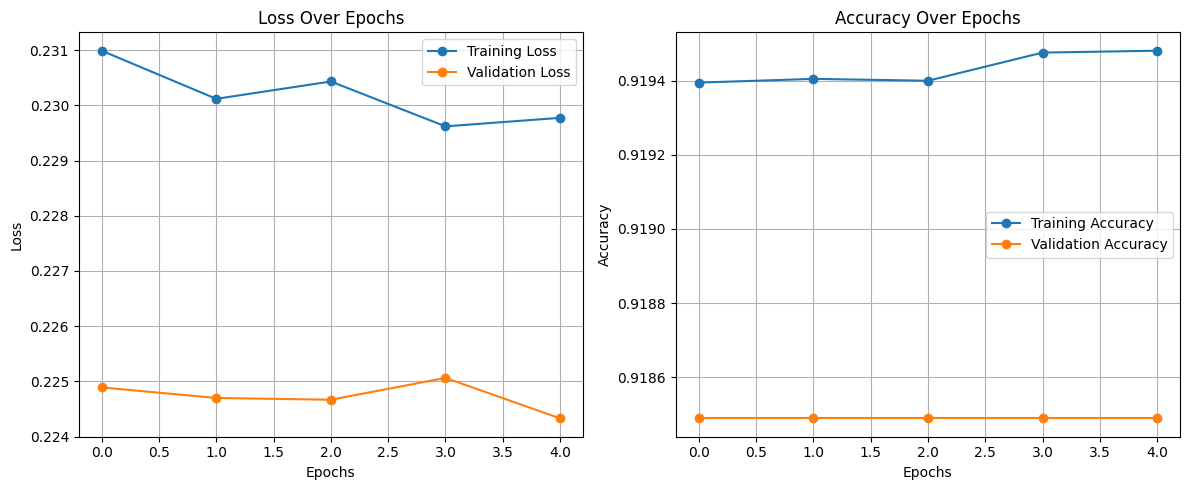

In [48]:
import matplotlib.pyplot as plt

# 훈련 및 검증 손실 시각화 
def plot_training_history(history):
    # 손실 그래프 
    plt.figure(figsize=(12, 5))

    # 손실 값 (Loss) 
    plt.subplot(1, 2, 1) 
    plt.plot(history.history['loss'], label='Training Loss', marker='o') 
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o') 
    plt.title('Loss Over Epochs') 
    plt.xlabel('Epochs') 
    plt.ylabel('Loss') 
    plt.legend()
    plt.grid(True)
    
    # 정확도 값 (Accuracy) 
    plt.subplot(1, 2, 2) 
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o') 
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o') 
        plt.title('Accuracy Over Epochs') 
        plt.xlabel('Epochs') 
        plt.ylabel('Accuracy') 
        plt.legend() 
        plt.grid(True)

    # 그래프 출력 
    plt.tight_layout() 
    plt.show()

# 함수 호출：모델 학습 결과 시각화 
plot_training_history(history)

#### (8) 모델 예측

In [50]:
# 예측 
predictions = model.predict(X_test_scaled) 
print(predictions)

1931/1931 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
[[0.01835668]
 [0.01387862]
 [0.00304398]
 ...
 [0.24618131]
 [0.02274012]
 [0.00324914]]


#### (9) 예측된 데이터를 0 또는 1로 변환

In [51]:
# 확률 기반 예측 결과를 0 또는 1로 변환 
binary_predictions = (predictions > 0.5).astype(int) 
print(binary_predictions)

[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


#### (10) 예측 데이터와 실제 데이터 비교

In [52]:
for pred, true in zip(binary_predictions, y_test):
    print(f"예측: {pred}, 실제: {true}, 일치 여부: {'O' if pred == true else 'X'}")

예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 1, 일치 여부: X
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 1, 일치 여부: X
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 1, 일치 여부: X
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O
예측: [0], 실제: 0, 일치 여부: O


#### (12) 모델 평가


▶ 정확도(Accuracy): 0.92

▶ 혼동행렬:
[[56777     0]
 [ 4994     0]]


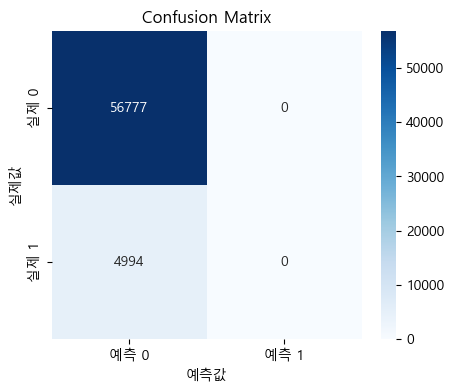


▶ 분류 성능 보고서:
              precision    recall  f1-score   support

           0     0.9192    1.0000    0.9579     56777
           1     0.0000    0.0000    0.0000      4994

    accuracy                         0.9192     61771
   macro avg     0.4596    0.5000    0.4789     61771
weighted avg     0.8448    0.9192    0.8804     61771



In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import seaborn as sns

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 정확도 
acc = accuracy_score(y_test, binary_predictions) 
print(f"\n▶ 정확도(Accuracy): {acc:.2f}")

# 혼동행렬 
cm = confusion_matrix(y_test, binary_predictions) 
print("\n▶ 혼동행렬:") 
print(cm)

# 시각화 
plt.figure(figsize=(5, 4)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['예측 0', '예측 1'], yticklabels=['실제 0', '실제 1']) 
plt.title("Confusion Matrix")
plt.ylabel("실제값") 
plt.xlabel("예측값") 
plt.show()

# 분류 리포트 
print("\n▶ 분류 성능 보고서:") 
#print(classification_report(y_test, binary_predictions))
print(
    classification_report(
        y_test,
        binary_predictions,
        digits=4,
        zero_division=0
    )
)